# Veri Ön İşleme

raw data -> modele uygun veri

İçerik:
- Aykırı değerler (Outliers)
- Kategorik veriler
- Data Transformation
- Veri tutarlılığı ve yinelenen kayıtlar (Data consistency)
- Veri bölme (Train/Test Split)
- Mini proje

## Outliers
Amaç: Veri setinde diğer örneklerden çok farklı olan, modelin öğrenme sürecini bozabilecek uç değerleri tespit etmek ve doğru şekilde yönetmek.

Yönetilemezse:
- Regresyon modellerinde yanlılığa sebep olabilir.
- STD, varyans, mean değerleri bozulabilir.
- Model noise'a duyarlı hale gelir.
****
**Outlier:** Veri setindeki diğer gözlemlerden istatistiksel olarak önemli ölçüde farklı olan gözlemlerdir.
Genelde veri toplama hatalarından, ölçüm cihazı hataları, gerçekten sıra dışı olaylardan kaynaklanır.
****
Örneğin:
Mesela bir sigorta şirketi araç hasar kayıtları 10.000 - 50.000 arasında olsun. Ama bir kaç kayıt 1.000.000 TL gibi uç değerlere sahip.
- lüks araç kazası
- Yanlışlıkla bir sıfır fazla atılmış.
Sonuç olarak bunu tespit edip anlamak gerekir.
----
İçerik Akışı:
- Aykırı değerlerin görselleştirilmesi
- IQR (Inter quantile range) ile outlier tespiti
- aykırı değer temizleme
- sonucun kontrolü

### Veri seti oluşturma

In [1]:


import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

# Örnek veri seti oluşturma

np.random.seed(42)

# normal dağılımlı bir hasar verisi, ort = 50000, std= 8000, 200 adet

hasar = np.random.normal(50000, 8000, 200)

# aykırı değerlerin eklenmesi

hasar = np.append(hasar, [150000, 170000, 200000])

df = pd.DataFrame({'hasar': hasar})

df.head()

,hasar
0,53973.713224
1,48893.885591
2,55181.508305
3,62184.238851
4,48126.773002


### Aykırı değerlerin görselleştirilmesi

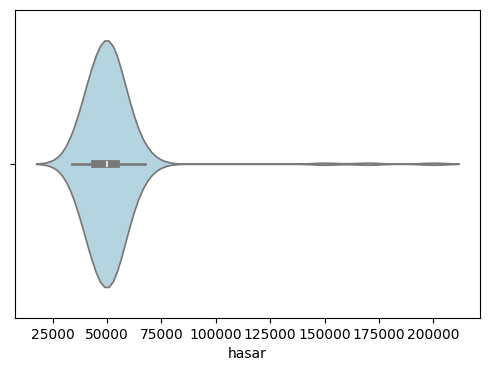

In [2]:
plt.figure(figsize=(6,4))
sns.violinplot(data = df, x = "hasar", color = "lightblue")
plt.show()

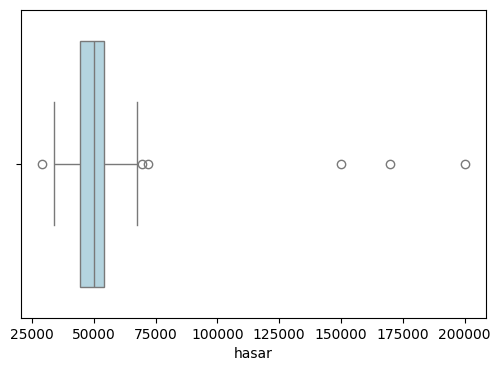

In [3]:
plt.figure(figsize=(6,4))
sns.boxplot(data = df, x = "hasar", color = "lightblue")
plt.show()

### IQR ile outlier tespiti

In [4]:
# çeyrek değerlerin hesaplanması
Q1 = df.hasar.quantile(0.25)
Q3 = df.hasar.quantile(0.75)

# IQR hesaplama
IQR = Q3 - Q1
print(IQR)

9786.317698634826


In [5]:
alt_sinir = Q1 - 1.5 * IQR
ust_sinir = Q3 + 1.5 * IQR

print(alt_sinir)
print(ust_sinir)


29792.21219022439
68937.48298476369


### Aykırı değerlerin tespiti

In [6]:
aykiri_degerler = df[(df.hasar < alt_sinir) | (df.hasar > ust_sinir)]
print(len(aykiri_degerler))
print(aykiri_degerler)

6
             hasar
74    29042.039167
113   69705.936900
179   71761.353333
200  150000.000000
201  170000.000000
202  200000.000000


### Aykırı değerlerin temizlenmesi

In [7]:
# sınırlandırma

df["hasar_sinirlandirilmis"] = np.where(df.hasar >ust_sinir,ust_sinir,
                                        np.where(df.hasar < alt_sinir, alt_sinir, df.hasar))
df

,hasar,hasar_sinirlandirilmis
0,53973.713224,53973.713224
1,48893.885591,48893.885591
2,55181.508305,55181.508305
3,62184.238851,62184.238851
4,48126.773002,48126.773002
...,...,...
198,50465.669748,50465.669748
199,40856.237617,40856.237617
200,150000.000000,68937.482985
201,170000.000000,68937.482985


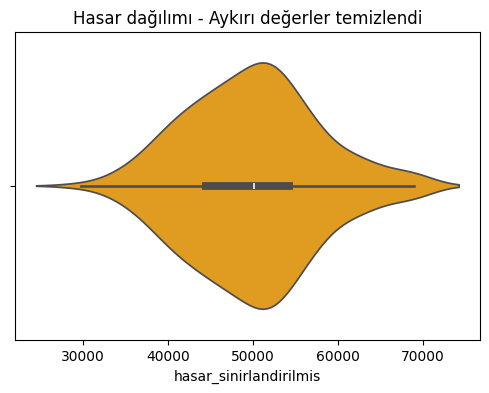

In [8]:
# Yeni dağılımı görselleştirme

plt.figure(figsize=(6,4))
sns.violinplot(data = df, x = "hasar_sinirlandirilmis", color = "orange")
plt.title("Hasar dağılımı - Aykırı değerler temizlendi")
plt.show()

### Sonucun kontrolü

In [9]:
print(f"Temizleme öncesi veri sayısı: {len(df)}")
print(f"Aykırı değer sayisi: {len(aykiri_degerler)}")
print(f"Temizleme sonrası minimum hasar kaydı değeri {df["hasar_sinirlandirilmis"].min()}")
print(f"Temizleme sonrası maksimum hasar kaydı değeri {df["hasar_sinirlandirilmis"].max()}")

Temizleme öncesi veri sayısı: 203
Aykırı değer sayisi: 6
Temizleme sonrası minimum hasar kaydı değeri 29792.21219022439
Temizleme sonrası maksimum hasar kaydı değeri 68937.48298476369


## Categorical Data
> Veri setlerindeki string sütunları sayısal değere çevirmek.

Kategorik veri: Sınırsız sayıda benzersiz değer alan değişkenler.
> cinsiyet, üyelik türü, şehir...

****
içerik planı:
1. Label encoding
2. One-Hot encoding
3. Dummy variable tuzağı önleme
4. Kodlanmmış veriyi df de birleştirme


In [10]:
"""
veri seti oluşturma : E-ticaret müşteri verileri
  cinsiyet
  üyelik türü
  şehir
Amaç: string verileri sayısala çevirme
"""

# örnek veri seti
data ={
    "cinsiyet": ["erkek", "erkek", "kadın", "erkek", "kadın"],
    "uyelik_turu": ["std", "VIP", "gold", "gold", "std"],
    "sehir": ["istanbul", "ankara", "izmir", "istanbul", "izmir"],
    "gelir": [5000, 6000,29000,5000,10000]
}
data = pd.DataFrame(data)
data

,cinsiyet,uyelik_turu,sehir,gelir
0,erkek,std,istanbul,5000
1,erkek,VIP,ankara,6000
2,kadın,gold,izmir,29000
3,erkek,gold,istanbul,5000
4,kadın,std,izmir,10000


### Label Encoding (Etiket kodlama)
Tanım: Her kategorik değere benzersiz bir sayı atanır.
Örneğin:
- Erkek -> 0
- Kadın -> 1
*****
Avantaj: Basit ve hafif bit yöntem

Dezavantaj: Sayılar model tarafından ordinal (sıralı) anlanabilir.


In [11]:
from sklearn.preprocessing import LabelEncoder

label_encoder = LabelEncoder()


In [12]:
data["cinsiyet_label"] = label_encoder.fit_transform(data["cinsiyet"])
data

,cinsiyet,uyelik_turu,sehir,gelir,cinsiyet_label
0,erkek,std,istanbul,5000,0
1,erkek,VIP,ankara,6000,0
2,kadın,gold,izmir,29000,1
3,erkek,gold,istanbul,5000,0
4,kadın,std,izmir,10000,1


In [13]:
data["uyelik_turu_label"] = label_encoder.fit_transform(data["uyelik_turu"])
data

,cinsiyet,uyelik_turu,sehir,gelir,cinsiyet_label,uyelik_turu_label
0,erkek,std,istanbul,5000,0,2
1,erkek,VIP,ankara,6000,0,0
2,kadın,gold,izmir,29000,1,1
3,erkek,gold,istanbul,5000,0,1
4,kadın,std,izmir,10000,1,2


### One-Hot Encoding
Tanım: Her kategorik değer için ayrı sütun oluşturulur. Eğer değer o kategoriye ait ise "1" değilse "0" olarak atanır.
****
uyelik_turu: std, gold
 * uyelik_turu_std
 * uyelik_turu_gold
****
Avantaj: model kategoriler arasında yanlış hiyerarşi kurmaz
Dezavantaj: Kategori sayısı çok olduğunda veri boyutu fazla büyür.


In [14]:
from sklearn.preprocessing import OneHotEncoder

one_hot_encoder = OneHotEncoder(sparse_output=False)
encoded_array = one_hot_encoder.fit_transform(data[["uyelik_turu"]])
encoded_array

array([[0., 0., 1.],
       [1., 0., 0.],
       [0., 1., 0.],
       [0., 1., 0.],
       [0., 0., 1.]])

In [15]:
# yeni sütun adları
encoded_columns = one_hot_encoder.get_feature_names_out(["uyelik_turu"])

In [16]:
# yeni df
encoded_df = pd.DataFrame(encoded_array, columns=encoded_columns)
encoded_df

,uyelik_turu_VIP,uyelik_turu_gold,uyelik_turu_std
0,0.0,0.0,1.0
1,1.0,0.0,0.0
2,0.0,1.0,0.0
3,0.0,1.0,0.0
4,0.0,0.0,1.0


### Dummy variable tuzağını önleme
One-Hot Encoding sonrasında tüm sütunlar modele dahil edilrise sütunlar arasında doğrusal bağımlılık oluşur. Bu durumda bir sütunu çıkarmamız gerekir, yani n sütundan n-1 kategoriye düşebiliriz.

In [17]:
encoded_df = encoded_df.drop(columns=["uyelik_turu_std"])
encoded_df

,uyelik_turu_VIP,uyelik_turu_gold
0,0.0,0.0
1,1.0,0.0
2,0.0,1.0
3,0.0,1.0
4,0.0,0.0


### Kodlanmış veriyi df de birleştirme

In [18]:
data_final = pd.concat([data, encoded_df], axis=1)
data_final

,cinsiyet,uyelik_turu,sehir,gelir,cinsiyet_label,uyelik_turu_label,uyelik_turu_VIP,uyelik_turu_gold
0,erkek,std,istanbul,5000,0,2,0.0,0.0
1,erkek,VIP,ankara,6000,0,0,1.0,0.0
2,kadın,gold,izmir,29000,1,1,0.0,1.0
3,erkek,gold,istanbul,5000,0,1,0.0,1.0
4,kadın,std,izmir,10000,1,2,0.0,0.0


In [19]:
data_final.drop(columns=["cinsiyet", "uyelik_turu", "uyelik_turu"], inplace=True)
data_final

,sehir,gelir,cinsiyet_label,uyelik_turu_label,uyelik_turu_VIP,uyelik_turu_gold
0,istanbul,5000,0,2,0.0,0.0
1,ankara,6000,0,0,1.0,0.0
2,izmir,29000,1,1,0.0,1.0
3,istanbul,5000,0,1,0.0,1.0
4,izmir,10000,1,2,0.0,0.0


In [20]:
encoded_sehir = one_hot_encoder.fit_transform(data_final[['sehir']])
encoded_sehir

array([[0., 1., 0.],
       [1., 0., 0.],
       [0., 0., 1.],
       [0., 1., 0.],
       [0., 0., 1.]])

In [21]:
en_sehir_col= one_hot_encoder.get_feature_names_out(['sehir'])

In [22]:
en_sehir = pd.DataFrame(encoded_sehir, columns=en_sehir_col)
en_sehir

,sehir_ankara,sehir_istanbul,sehir_izmir
0,0.0,1.0,0.0
1,1.0,0.0,0.0
2,0.0,0.0,1.0
3,0.0,1.0,0.0
4,0.0,0.0,1.0


In [23]:
data_final

,sehir,gelir,cinsiyet_label,uyelik_turu_label,uyelik_turu_VIP,uyelik_turu_gold
0,istanbul,5000,0,2,0.0,0.0
1,ankara,6000,0,0,1.0,0.0
2,izmir,29000,1,1,0.0,1.0
3,istanbul,5000,0,1,0.0,1.0
4,izmir,10000,1,2,0.0,0.0


In [24]:
data_final = pd.concat([data_final, en_sehir], axis =1)
data_final = data_final.drop(columns=["sehir_izmir", "sehir"])
data_final

,gelir,cinsiyet_label,uyelik_turu_label,uyelik_turu_VIP,uyelik_turu_gold,sehir_ankara,sehir_istanbul
0,5000,0,2,0.0,0.0,0.0,1.0
1,6000,0,0,1.0,0.0,1.0,0.0
2,29000,1,1,0.0,1.0,0.0,0.0
3,5000,0,1,0.0,1.0,0.0,1.0
4,10000,1,2,0.0,0.0,0.0,0.0


## Veri Dönüşümleri (Data Transformation)
Amaç: Veri setindeki değişkenlerin türlerni, biçimlerini, dağılımlarını modelleme sürecine uygun hale getirmek.

Veri dönüşümleri sayesinde (içerik):
  - Sayısal sütunlar gerçekten sayısal sütun haline gelir.
  - Tarihler -> datetime
  - Metinler temizlenir
  - Eğik (skewed) dağılımlar logaritmik dönüşüm ile dengelenir.
****
Veri dönüşümü: Ham veriyi analiz veya modelleme için uygun forma getirme sürecidir.


In [42]:
"""
Veri seti oluşturma: yas, tarih, metin
"""

import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

# örnek veri seti
data = {
    "yas": ["25", "30", "35", "40", "45"],
    "ise_baslama" : ["2020/01/05", "2019/03/10", "2021/07/10", "2018/12/20", "2017/09/01"],
    "pozisyon": ["Muhendis", "mühendis ", "mühendıs", "MüheNdis", " Mühendis"],
    "maas": [5000,7000,12000,8000,20000]
}
df = pd.DataFrame(data)
df

,yas,ise_baslama,pozisyon,maas
0,25,2020/01/05,Muhendis,5000
1,30,2019/03/10,mühendis,7000
2,35,2021/07/10,mühendıs,12000
3,40,2018/12/20,MüheNdis,8000
4,45,2017/09/01,Mühendis,20000


In [43]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5 entries, 0 to 4
Data columns (total 4 columns):
 #   Column       Non-Null Count  Dtype 
---  ------       --------------  ----- 
 0   yas          5 non-null      object
 1   ise_baslama  5 non-null      object
 2   pozisyon     5 non-null      object
 3   maas         5 non-null      int64 
dtypes: int64(1), object(3)
memory usage: 292.0+ bytes


### tip dönüşümü

In [44]:

df["yas"] = df['yas'].astype(int)
df.dtypes

,0
yas,int64
ise_baslama,object
pozisyon,object
maas,int64


In [45]:
df['ise_baslama'] = pd.to_datetime(df['ise_baslama'])
df.dtypes

,0
yas,int64
ise_baslama,datetime64[ns]
pozisyon,object
maas,int64


In [46]:
df["yil"] = df["ise_baslama"].dt.year # date time çevirdiğimiz için fonk ları rahat kullanabiliyoruz
df

,yas,ise_baslama,pozisyon,maas,yil
0,25,2020-01-05,Muhendis,5000,2020
1,30,2019-03-10,mühendis,7000,2019
2,35,2021-07-10,mühendıs,12000,2021
3,40,2018-12-20,MüheNdis,8000,2018
4,45,2017-09-01,Mühendis,20000,2017


In [47]:
df["ay"] = df["ise_baslama"].dt.month
df

,yas,ise_baslama,pozisyon,maas,yil,ay
0,25,2020-01-05,Muhendis,5000,2020,1
1,30,2019-03-10,mühendis,7000,2019,3
2,35,2021-07-10,mühendıs,12000,2021,7
3,40,2018-12-20,MüheNdis,8000,2018,12
4,45,2017-09-01,Mühendis,20000,2017,9


### metinleri temizle


In [61]:
df["pozisyon_temiz"] = (
    df["pozisyon"]
    .str.strip() # Baştaki ve sondaki gereksiz boşlukları kalıdır
    .str.lower() # küçük harfe çevir
    .str.replace("ü", "u")
    .str.replace("ı", "i")
)

df

,yas,ise_baslama,pozisyon,maas,yil,ay,pozisyon_temiz
0,25,2020-01-05,Muhendis,5000,2020,1,muhendis
1,30,2019-03-10,mühendis,7000,2019,3,muhendis
2,35,2021-07-10,mühendıs,12000,2021,7,muhendis
3,40,2018-12-20,MüheNdis,8000,2018,12,muhendis
4,45,2017-09-01,Mühendis,20000,2017,9,muhendis


### logaritmik dönüşüm

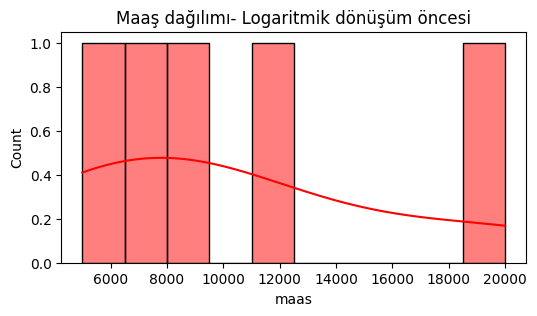

In [63]:
plt.figure(figsize=(6,3))
sns.histplot(df['maas'], bins = 10, color ="red", kde = True)
plt.title("Maaş dağılımı- Logaritmik dönüşüm öncesi")
plt.show()

In [64]:
df['maas_log'] = np.log1p(df["maas"])
df

,yas,ise_baslama,pozisyon,maas,yil,ay,pozisyon_temiz,maas_log
0,25,2020-01-05,Muhendis,5000,2020,1,muhendis,8.517393
1,30,2019-03-10,mühendis,7000,2019,3,muhendis,8.853808
2,35,2021-07-10,mühendıs,12000,2021,7,muhendis,9.392745
3,40,2018-12-20,MüheNdis,8000,2018,12,muhendis,8.987322
4,45,2017-09-01,Mühendis,20000,2017,9,muhendis,9.903538


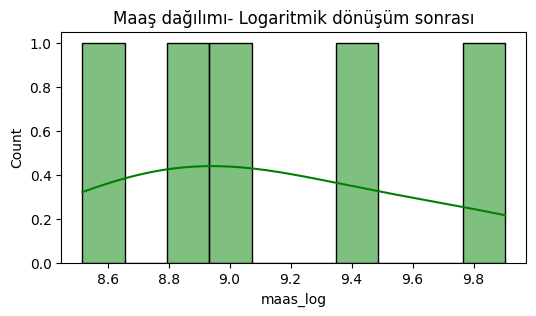

In [65]:
plt.figure(figsize=(6,3))
sns.histplot(df['maas_log'], bins = 10, color ="green", kde = True)
plt.title("Maaş dağılımı- Logaritmik dönüşüm sonrası")
plt.show()

## Data Consistency ve Yinelenen Kayıtlar
Amaç: Veri setinin benzersiz ve tutarlı olması gerekmektedir.
- Yinelenen satırları tespit et ve kaldır
- Sütun adlarındaki hataları düzeltmek
- Karakter, biçim veya yazım farklarını gidermek
- verinin istatistiksel tutarlılığını sağlamak
****
Veri Tutarlılığı sağlanmazsa:
  - Aynı gözlem birden fazla kez öğrenebilir
  - İstatistiksel hesaplamalarda yanılabilir
  - Tahmin doğruluğu ciddi şekilde düşebilir
****
Data consistency, verilerin tekil, doğru biçimde ve uyumlu olma durumudur. Verideki tüm değerlerin aynı anlamı taşıması ve aynı formatta olması gerekir.
****
İçerik:
- Yinelenen kayıtların tespiti
- Sütun adlarının temizlenmesi
- Metin tutarlılığı
- Mantıksal tutarlılık kontrolü


In [68]:
"""
Veri seti: Tekrar eden satırlar, biçimsel tutarsızlıklar ve mantıksal hatalar,
aynı müşterinin farklı yazımlarla sisteme kaydedilmesi
"""

# örnek veri seti

data = {
    "musteri_adi*": ["Ali Veli", "ali veli", "Ali Veli", "Kaan Can", "Kaan Can"],
    "Sehir": ["Ankara", "ANKARA", "ankara", "İzmir", "İzmir"],
    "yas ": [28,28,28,35,35],
    "maas" : [7000, 7000, 7000, 8500, 8500]
}
df = pd.DataFrame(data)
df



,musteri_adi*,Sehir,yas,maas
0,Ali Veli,Ankara,28,7000
1,ali veli,ANKARA,28,7000
2,Ali Veli,ankara,28,7000
3,Kaan Can,İzmir,35,8500
4,Kaan Can,İzmir,35,8500


In [69]:
df.columns

Index(['musteri_adi*', 'Sehir', 'yas ', 'maas'], dtype='object')

### Sütunların Temizlenmesi

In [70]:
df.columns = df.columns.str.strip().str.lower().str.replace("*", "")
df.columns

Index(['musteri_adi', 'sehir', 'yas', 'maas'], dtype='object')

### Yinelenen Kayıtların Tespiti

In [71]:
dups = df.duplicated()
dups

,0
0,False
1,False
2,False
3,False
4,True


In [72]:
# Sadece yinelenenleri görüntüler
df[dups]

,musteri_adi,sehir,yas,maas
4,Kaan Can,İzmir,35,8500


### Tekrarlanan satırları sil

In [73]:
df = df.drop_duplicates()
df

,musteri_adi,sehir,yas,maas
0,Ali Veli,Ankara,28,7000
1,ali veli,ANKARA,28,7000
2,Ali Veli,ankara,28,7000
3,Kaan Can,İzmir,35,8500


### Metin tutarlılığı sağlama

In [75]:
df["musteri_adi"] = (
    df["musteri_adi"]
    .str.strip()
    .str.lower()
    .str.replace(r"\s", " ", regex=True) # çift boşlukları tek yapar
)
df

/tmp/ipykernel_34636/3887263813.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df["musteri_adi"] = (


,musteri_adi,sehir,yas,maas
0,ali veli,Ankara,28,7000
1,ali veli,ANKARA,28,7000
2,ali veli,ankara,28,7000
3,kaan can,İzmir,35,8500


In [78]:
df["sehir"] = df["sehir"].str.strip().str.title() # ankara izmir format düzeltme
df

/tmp/ipykernel_34636/1514671862.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df["sehir"] = df["sehir"].str.strip().str.title() # ankara izmir format düzeltme


,musteri_adi,sehir,yas,maas
0,ali veli,Ankara,28,7000
1,ali veli,Ankara,28,7000
2,ali veli,Ankara,28,7000
3,kaan can,İzmir,35,8500


### Mantıksal tutarlılık kontrolü

In [82]:
# yaş sütunu mantıklı mı
mantiksiz = df[(df["yas"] < 0) | (df["yas"] > 120)]
print(mantiksiz if not mantiksiz.empty else "Tüm yaş değerleri mantıklı")
df

Tüm yaş değerleri mantıklı


,musteri_adi,sehir,yas,maas
0,ali veli,Ankara,28,7000
1,ali veli,Ankara,28,7000
2,ali veli,Ankara,28,7000
3,kaan can,İzmir,35,8500


In [83]:
dumps = df.duplicated()
df[dumps]

,musteri_adi,sehir,yas,maas
1,ali veli,Ankara,28,7000
2,ali veli,Ankara,28,7000


In [84]:
df = df.drop_duplicates()
df

,musteri_adi,sehir,yas,maas
0,ali veli,Ankara,28,7000
3,kaan can,İzmir,35,8500


## Veri bölme (Train/Test split)
Bir makine öğrenmesi modelini eğitirken, elimizdeki tüm veriyi hem eğitim hem de test için aynı anda kullanamayız. Çünkü bu durumda model, test verilerini zaten öğrenmiş olur ve gerçekte performansı doğru ölçemeyiz.
Bu nedenle veriyi ikiye ayırmak gerekir.
- Train Dataset
- Test Dataset
-----
Veri bölme (Train/test Split): Mevcut veri setini belirli oranlarda eğitim ve test gurplarına ayırma işlemidir.



In [96]:
"""
Veri seti: müşteri veri seti
"""

data = {
    "gelir": [5000, 6000, 7000, 8000, 9000,10000, 12000, 13000, 14000, 15000],
    "cinsiyet": ["erkek", "erkek", "erkek", "erkek", "erkek", "erkek", "kadın", "kadın", "kadın", "kadın"],
    "yas": [25, 26, 27, 28, 29, 30, 31, 32, 33, 34],
    "kredi_durumu": ["odedi", "odemedi", "odemedi","odedi", "odemedi", "odemedi","odedi", "odemedi", "odemedi","odemedi" ]
}
df = pd.DataFrame(data)

df

,gelir,cinsiyet,yas,kredi_durumu
0,5000,erkek,25,odedi
1,6000,erkek,26,odemedi
2,7000,erkek,27,odemedi
3,8000,erkek,28,odedi
4,9000,erkek,29,odemedi
5,10000,erkek,30,odemedi
6,12000,kadın,31,odedi
7,13000,kadın,32,odemedi
8,14000,kadın,33,odemedi
9,15000,kadın,34,odemedi


In [97]:
# bağımsız değişkenler (X: gelir, yas, cinsiyet), bağımsız değişkenler (y: kredi durumu)
df["kredi_durumu"] = df["kredi_durumu"].map({"odedi": 1, "odemedi": 0})
df


,gelir,cinsiyet,yas,kredi_durumu
0,5000,erkek,25,1
1,6000,erkek,26,0
2,7000,erkek,27,0
3,8000,erkek,28,1
4,9000,erkek,29,0
5,10000,erkek,30,0
6,12000,kadın,31,1
7,13000,kadın,32,0
8,14000,kadın,33,0
9,15000,kadın,34,0


In [98]:
x = df[["gelir", "yas","cinsiyet"]]
y = df["kredi_durumu"]

In [100]:
from sklearn.model_selection import train_test_split

x_train, x_test, y_train, y_test = train_test_split(
    x, y,
    test_size=0.2,
    random_state=42, # tekrarlanabilirlik
    stratify = y # sınıf dengesini koruma
)


In [101]:
x_train.shape

(8, 3)

In [102]:
y_train.shape

(8,)

## Mini proje: Boston Housing Veri Seti Temizleme


In [177]:
# veri yükleme
url = "https://raw.githubusercontent.com/selva86/datasets/master/BostonHousing.csv"
df = pd.read_csv(url)
df

,crim,zn,indus,chas,nox,rm,age,dis,rad,tax,ptratio,b,lstat,medv
0,0.00632,18.0,2.31,0,0.538,6.575,65.2,4.0900,1,296,15.3,396.90,4.98,24.0
1,0.02731,0.0,7.07,0,0.469,6.421,78.9,4.9671,2,242,17.8,396.90,9.14,21.6
2,0.02729,0.0,7.07,0,0.469,7.185,61.1,4.9671,2,242,17.8,392.83,4.03,34.7
3,0.03237,0.0,2.18,0,0.458,6.998,45.8,6.0622,3,222,18.7,394.63,2.94,33.4
4,0.06905,0.0,2.18,0,0.458,7.147,54.2,6.0622,3,222,18.7,396.90,5.33,36.2
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
501,0.06263,0.0,11.93,0,0.573,6.593,69.1,2.4786,1,273,21.0,391.99,9.67,22.4
502,0.04527,0.0,11.93,0,0.573,6.120,76.7,2.2875,1,273,21.0,396.90,9.08,20.6
503,0.06076,0.0,11.93,0,0.573,6.976,91.0,2.1675,1,273,21.0,396.90,5.64,23.9
504,0.10959,0.0,11.93,0,0.573,6.794,89.3,2.3889,1,273,21.0,393.45,6.48,22.0


In [178]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 506 entries, 0 to 505
Data columns (total 14 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   crim     506 non-null    float64
 1   zn       506 non-null    float64
 2   indus    506 non-null    float64
 3   chas     506 non-null    int64  
 4   nox      506 non-null    float64
 5   rm       506 non-null    float64
 6   age      506 non-null    float64
 7   dis      506 non-null    float64
 8   rad      506 non-null    int64  
 9   tax      506 non-null    int64  
 10  ptratio  506 non-null    float64
 11  b        506 non-null    float64
 12  lstat    506 non-null    float64
 13  medv     506 non-null    float64
dtypes: float64(11), int64(3)
memory usage: 55.5 KB


### Aykırı değerler

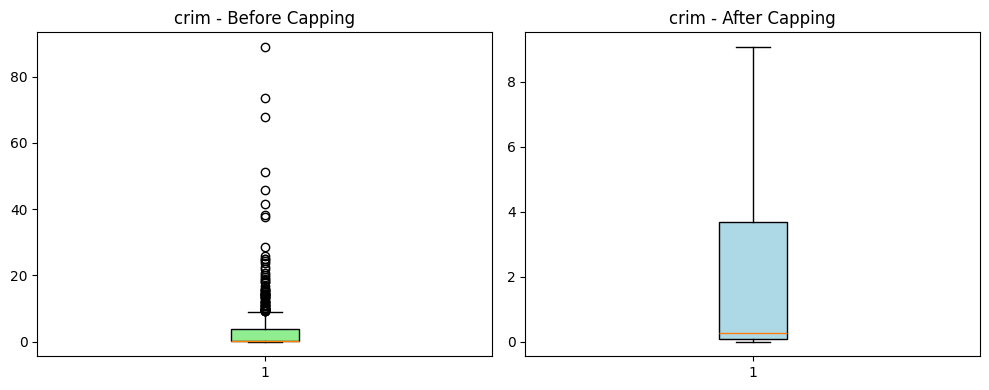

In [179]:
# 1. Setup the figure and axes
fig, axs = plt.subplots(1, 2, figsize=(10, 4))

# 2. Plot "Before" on the first subplot
axs[0].boxplot(df["crim"], patch_artist=True,
               boxprops=dict(facecolor="lightgreen"))
axs[0].set_title("crim - Before Capping")

# 3. Calculate IQR and Cap Outliers
Q1, Q3 = df["crim"].quantile([0.25, 0.75])
IQR = Q3 - Q1
alt_sinir = Q1 - 1.5 * IQR
ust_sinir = Q3 + 1.5 * IQR

# Apply capping
df["crim"] = np.where(df["crim"] > ust_sinir, ust_sinir,
                    np.where(df["crim"] < alt_sinir, alt_sinir, df["crim"]))

# 4. Plot "After" on the second subplot
axs[1].boxplot(df["crim"], patch_artist=True,
               boxprops=dict(facecolor="lightblue")) # Changed color for contrast
axs[1].set_title("crim - After Capping")

# 5. Finalize layout and show once
plt.tight_layout()
plt.show()

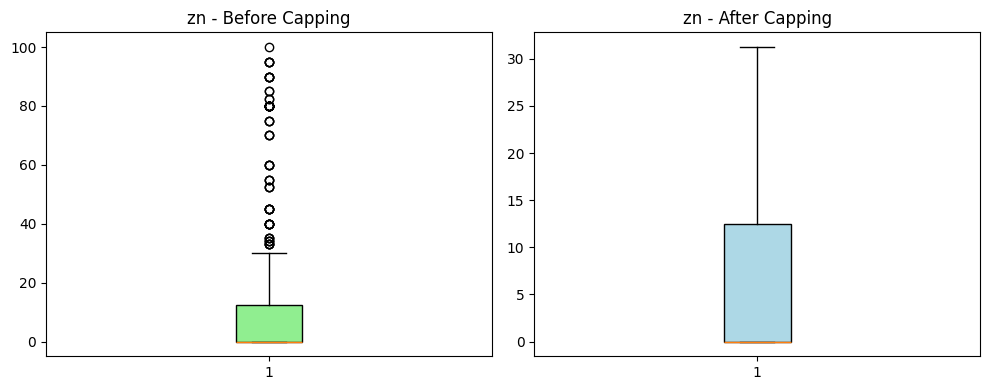

In [180]:

# 1. Setup the figure and axes
fig, axs = plt.subplots(1, 2, figsize=(10, 4))

# 2. Plot "Before" on the first subplot
axs[0].boxplot(df["zn"], patch_artist=True,
               boxprops=dict(facecolor="lightgreen"))
axs[0].set_title("zn - Before Capping")

# 3. Calculate IQR and Cap Outliers
Q1, Q3 = df["zn"].quantile([0.25, 0.75])
IQR = Q3 - Q1
alt_sinir = Q1 - 1.5 * IQR
ust_sinir = Q3 + 1.5 * IQR

# Apply capping
df["zn"] = np.where(df["zn"] > ust_sinir, ust_sinir,
                    np.where(df["zn"] < alt_sinir, alt_sinir, df["zn"]))

# 4. Plot "After" on the second subplot
axs[1].boxplot(df["zn"], patch_artist=True,
               boxprops=dict(facecolor="lightblue")) # Changed color for contrast
axs[1].set_title("zn - After Capping")

# 5. Finalize layout and show once
plt.tight_layout()
plt.show()

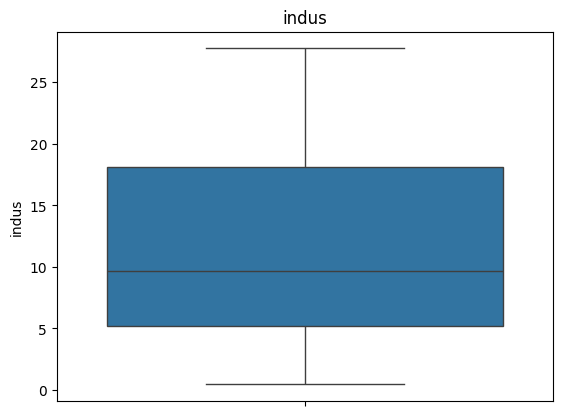

In [181]:
sns.boxplot(df["indus"])
plt.title("indus")
plt.show()


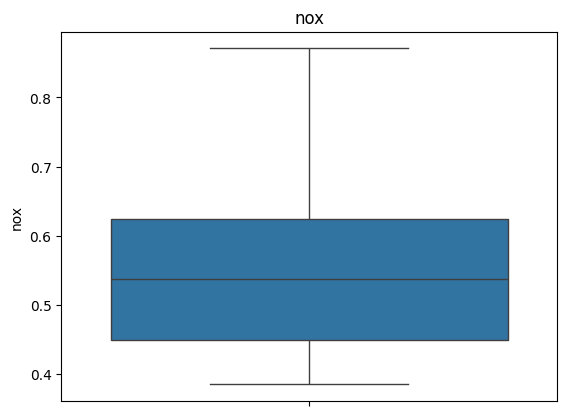

In [182]:
sns.boxplot(df["nox"])
plt.title("nox")
plt.show()

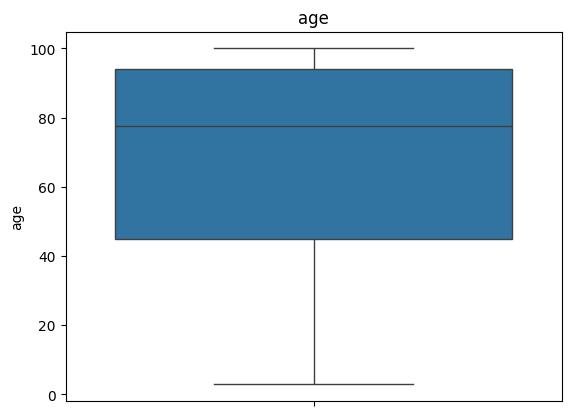

In [183]:
sns.boxplot(df["age"])
plt.title("age")
plt.show()

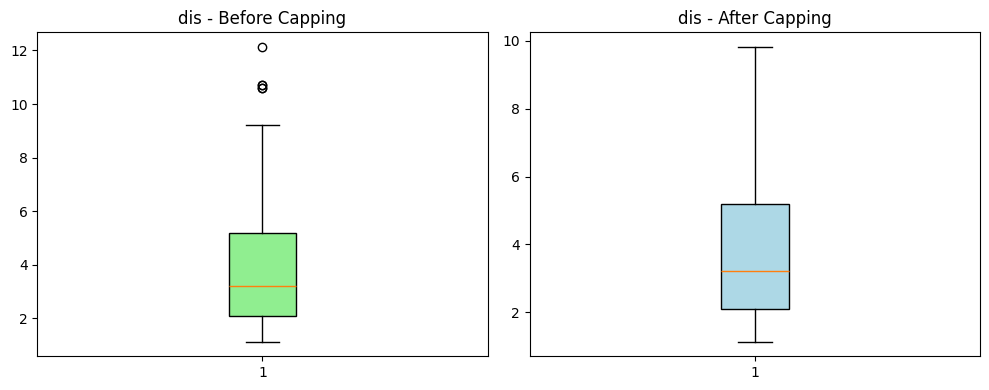

In [184]:
# 1. Setup the figure and axes
fig, axs = plt.subplots(1, 2, figsize=(10, 4))

# 2. Plot "Before" on the first subplot
axs[0].boxplot(df["dis"], patch_artist=True,
               boxprops=dict(facecolor="lightgreen"))
axs[0].set_title("dis - Before Capping")

# 3. Calculate IQR and Cap Outliers
Q1, Q3 = df["dis"].quantile([0.25, 0.75])
IQR = Q3 - Q1
alt_sinir = Q1 - 1.5 * IQR
ust_sinir = Q3 + 1.5 * IQR

# Apply capping
df["dis"] = np.where(df["dis"] > ust_sinir, ust_sinir,
                    np.where(df["dis"] < alt_sinir, alt_sinir, df["dis"]))

# 4. Plot "After" on the second subplot
axs[1].boxplot(df["dis"], patch_artist=True,
               boxprops=dict(facecolor="lightblue")) # Changed color for contrast
axs[1].set_title("dis - After Capping")

# 5. Finalize layout and show once
plt.tight_layout()
plt.show()

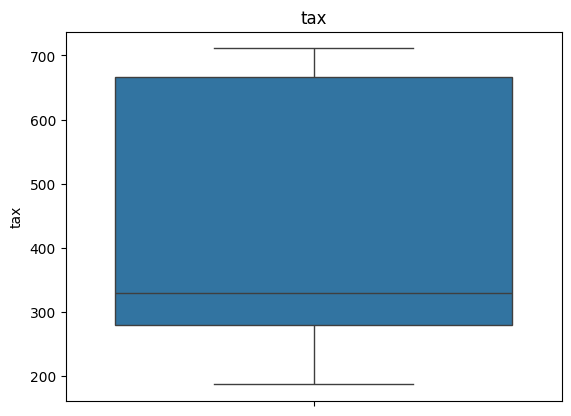

In [185]:
sns.boxplot(df["tax"])
plt.title("tax")
plt.show()

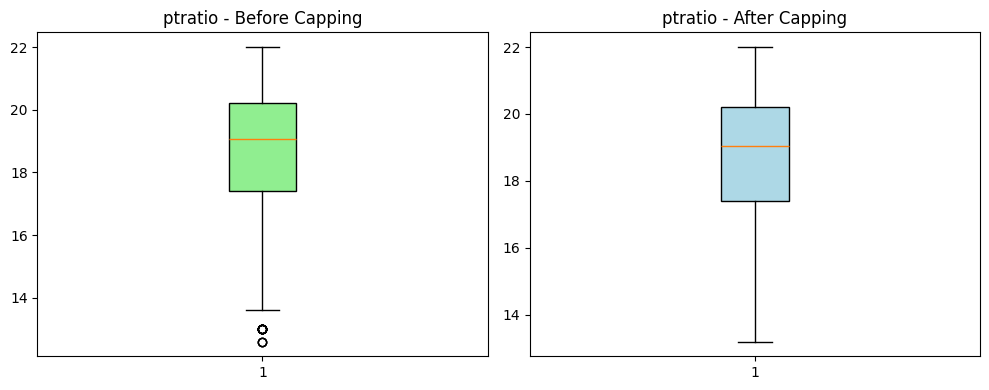

In [186]:
# 1. Setup the figure and axes
fig, axs = plt.subplots(1, 2, figsize=(10, 4))

# 2. Plot "Before" on the first subplot
axs[0].boxplot(df["ptratio"], patch_artist=True,
               boxprops=dict(facecolor="lightgreen"))
axs[0].set_title("ptratio - Before Capping")

# 3. Calculate IQR and Cap Outliers
Q1, Q3 = df["ptratio"].quantile([0.25, 0.75])
IQR = Q3 - Q1
alt_sinir = Q1 - 1.5 * IQR
ust_sinir = Q3 + 1.5 * IQR

# Apply capping
df["ptratio"] = np.where(df["ptratio"] > ust_sinir, ust_sinir,
                    np.where(df["ptratio"] < alt_sinir, alt_sinir, df["ptratio"]))

# 4. Plot "After" on the second subplot
axs[1].boxplot(df["ptratio"], patch_artist=True,
               boxprops=dict(facecolor="lightblue")) # Changed color for contrast
axs[1].set_title("ptratio - After Capping")

# 5. Finalize layout and show once
plt.tight_layout()
plt.show()

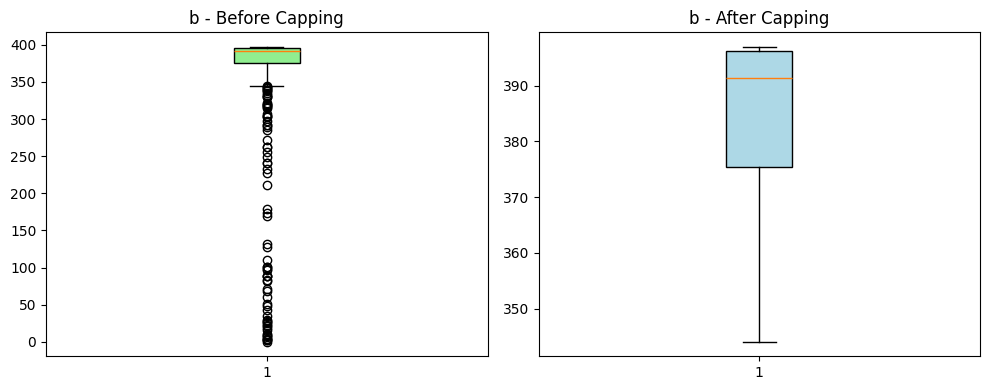

In [187]:
# 1. Setup the figure and axes
fig, axs = plt.subplots(1, 2, figsize=(10, 4))

# 2. Plot "Before" on the first subplot
axs[0].boxplot(df["b"], patch_artist=True,
               boxprops=dict(facecolor="lightgreen"))
axs[0].set_title("b - Before Capping")

# 3. Calculate IQR and Cap Outliers
Q1, Q3 = df["b"].quantile([0.25, 0.75])
IQR = Q3 - Q1
alt_sinir = Q1 - 1.5 * IQR
ust_sinir = Q3 + 1.5 * IQR

# Apply capping
df["b"] = np.where(df["b"] > ust_sinir, ust_sinir,
                    np.where(df["b"] < alt_sinir, alt_sinir, df["b"]))

# 4. Plot "After" on the second subplot
axs[1].boxplot(df["b"], patch_artist=True,
               boxprops=dict(facecolor="lightblue")) # Changed color for contrast
axs[1].set_title("b - After Capping")

# 5. Finalize layout and show once
plt.tight_layout()
plt.show()

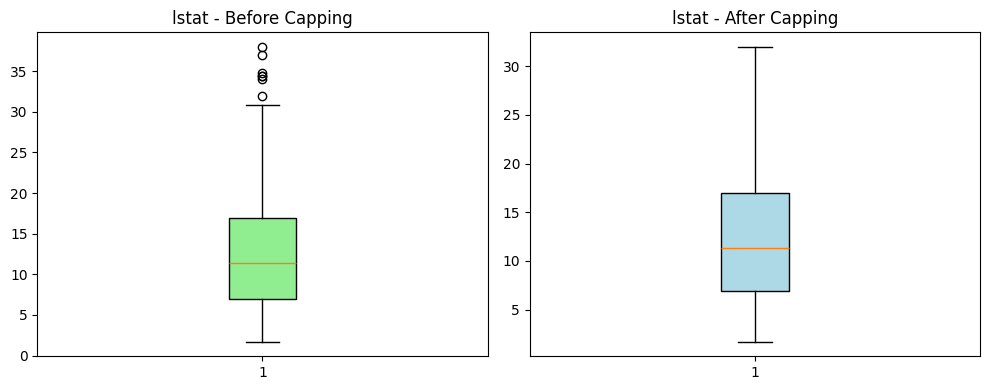

In [188]:
# 1. Setup the figure and axes
fig, axs = plt.subplots(1, 2, figsize=(10, 4))

# 2. Plot "Before" on the first subplot
axs[0].boxplot(df["lstat"], patch_artist=True,
               boxprops=dict(facecolor="lightgreen"))
axs[0].set_title("lstat - Before Capping")

# 3. Calculate IQR and Cap Outliers
Q1, Q3 = df["lstat"].quantile([0.25, 0.75])
IQR = Q3 - Q1
alt_sinir = Q1 - 1.5 * IQR
ust_sinir = Q3 + 1.5 * IQR

# Apply capping
df["lstat"] = np.where(df["lstat"] > ust_sinir, ust_sinir,
                    np.where(df["lstat"] < alt_sinir, alt_sinir, df["lstat"]))

# 4. Plot "After" on the second subplot
axs[1].boxplot(df["lstat"], patch_artist=True,
               boxprops=dict(facecolor="lightblue")) # Changed color for contrast
axs[1].set_title("lstat - After Capping")

# 5. Finalize layout and show once
plt.tight_layout()
plt.show()

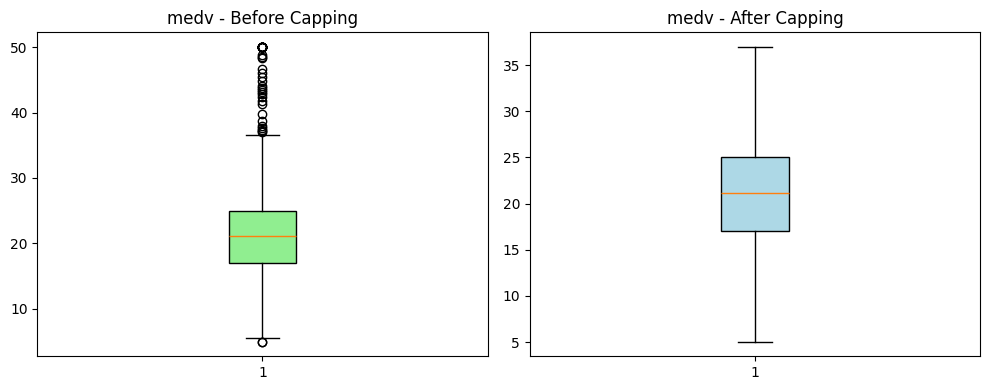

In [189]:
# 1. Setup the figure and axes
fig, axs = plt.subplots(1, 2, figsize=(10, 4))

# 2. Plot "Before" on the first subplot
axs[0].boxplot(df["medv"], patch_artist=True,
               boxprops=dict(facecolor="lightgreen"))
axs[0].set_title("medv - Before Capping")

# 3. Calculate IQR and Cap Outliers
Q1, Q3 = df["medv"].quantile([0.25, 0.75])
IQR = Q3 - Q1
alt_sinir = Q1 - 1.5 * IQR
ust_sinir = Q3 + 1.5 * IQR

# Apply capping
df["medv"] = np.where(df["medv"] > ust_sinir, ust_sinir,
                    np.where(df["medv"] < alt_sinir, alt_sinir, df["medv"]))

# 4. Plot "After" on the second subplot
axs[1].boxplot(df["medv"], patch_artist=True,
               boxprops=dict(facecolor="lightblue")) # Changed color for contrast
axs[1].set_title("medv - After Capping")

# 5. Finalize layout and show once
plt.tight_layout()
plt.show()

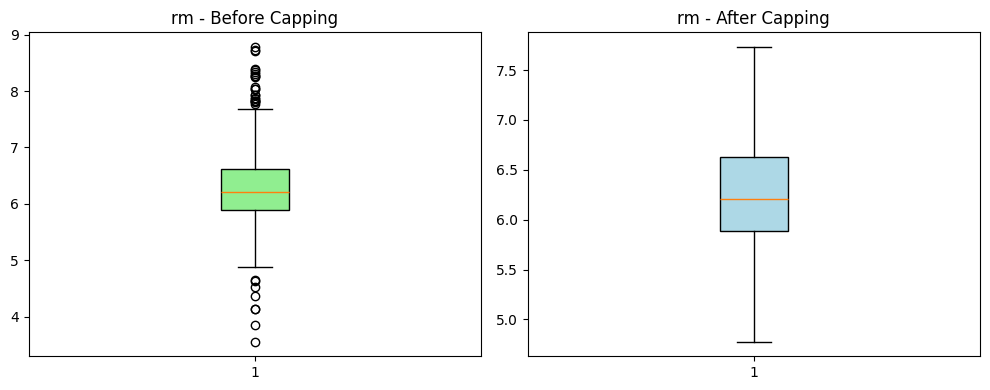

In [190]:
# 1. Setup the figure and axes
fig, axs = plt.subplots(1, 2, figsize=(10, 4))

# 2. Plot "Before" on the first subplot
axs[0].boxplot(df["rm"], patch_artist=True,
               boxprops=dict(facecolor="lightgreen"))
axs[0].set_title("rm - Before Capping")

# 3. Calculate IQR and Cap Outliers
Q1, Q3 = df["rm"].quantile([0.25, 0.75])
IQR = Q3 - Q1
alt_sinir = Q1 - 1.5 * IQR
ust_sinir = Q3 + 1.5 * IQR

# Apply capping
df["rm"] = np.where(df["rm"] > ust_sinir, ust_sinir,
                    np.where(df["rm"] < alt_sinir, alt_sinir, df["rm"]))

# 4. Plot "After" on the second subplot
axs[1].boxplot(df["rm"], patch_artist=True,
               boxprops=dict(facecolor="lightblue")) # Changed color for contrast
axs[1].set_title("rm - After Capping")

# 5. Finalize layout and show once
plt.tight_layout()
plt.show()





### Kategorik veriyi dönüştürme


In [193]:
# chas -> 0-1
df['chas'] = df["chas"].astype(int)
df

,crim,zn,indus,chas,nox,rm,age,dis,rad,tax,ptratio,b,lstat,medv
0,0.00632,18.0,2.31,0,0.538,6.575,65.2,4.0900,1,296,15.3,396.90,4.98,24.0
1,0.02731,0.0,7.07,0,0.469,6.421,78.9,4.9671,2,242,17.8,396.90,9.14,21.6
2,0.02729,0.0,7.07,0,0.469,7.185,61.1,4.9671,2,242,17.8,392.83,4.03,34.7
3,0.03237,0.0,2.18,0,0.458,6.998,45.8,6.0622,3,222,18.7,394.63,2.94,33.4
4,0.06905,0.0,2.18,0,0.458,7.147,54.2,6.0622,3,222,18.7,396.90,5.33,36.2
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
501,0.06263,0.0,11.93,0,0.573,6.593,69.1,2.4786,1,273,21.0,391.99,9.67,22.4
502,0.04527,0.0,11.93,0,0.573,6.120,76.7,2.2875,1,273,21.0,396.90,9.08,20.6
503,0.06076,0.0,11.93,0,0.573,6.976,91.0,2.1675,1,273,21.0,396.90,5.64,23.9
504,0.10959,0.0,11.93,0,0.573,6.794,89.3,2.3889,1,273,21.0,393.45,6.48,22.0


### Veri dönüştürme

In [194]:
df["lstat_log"] = np.log1p(df['lstat'])
df

,crim,zn,indus,chas,nox,rm,age,dis,rad,tax,ptratio,b,lstat,medv,lstat_log
0,0.00632,18.0,2.31,0,0.538,6.575,65.2,4.0900,1,296,15.3,396.90,4.98,24.0,1.788421
1,0.02731,0.0,7.07,0,0.469,6.421,78.9,4.9671,2,242,17.8,396.90,9.14,21.6,2.316488
2,0.02729,0.0,7.07,0,0.469,7.185,61.1,4.9671,2,242,17.8,392.83,4.03,34.7,1.615420
3,0.03237,0.0,2.18,0,0.458,6.998,45.8,6.0622,3,222,18.7,394.63,2.94,33.4,1.371181
4,0.06905,0.0,2.18,0,0.458,7.147,54.2,6.0622,3,222,18.7,396.90,5.33,36.2,1.845300
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
501,0.06263,0.0,11.93,0,0.573,6.593,69.1,2.4786,1,273,21.0,391.99,9.67,22.4,2.367436
502,0.04527,0.0,11.93,0,0.573,6.120,76.7,2.2875,1,273,21.0,396.90,9.08,20.6,2.310553
503,0.06076,0.0,11.93,0,0.573,6.976,91.0,2.1675,1,273,21.0,396.90,5.64,23.9,1.893112
504,0.10959,0.0,11.93,0,0.573,6.794,89.3,2.3889,1,273,21.0,393.45,6.48,22.0,2.012233


### Tutarlılık kontrolü


In [196]:
df = df.drop_duplicates()
df

,crim,zn,indus,chas,nox,rm,age,dis,rad,tax,ptratio,b,lstat,medv,lstat_log
0,0.00632,18.0,2.31,0,0.538,6.575,65.2,4.0900,1,296,15.3,396.90,4.98,24.0,1.788421
1,0.02731,0.0,7.07,0,0.469,6.421,78.9,4.9671,2,242,17.8,396.90,9.14,21.6,2.316488
2,0.02729,0.0,7.07,0,0.469,7.185,61.1,4.9671,2,242,17.8,392.83,4.03,34.7,1.615420
3,0.03237,0.0,2.18,0,0.458,6.998,45.8,6.0622,3,222,18.7,394.63,2.94,33.4,1.371181
4,0.06905,0.0,2.18,0,0.458,7.147,54.2,6.0622,3,222,18.7,396.90,5.33,36.2,1.845300
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
501,0.06263,0.0,11.93,0,0.573,6.593,69.1,2.4786,1,273,21.0,391.99,9.67,22.4,2.367436
502,0.04527,0.0,11.93,0,0.573,6.120,76.7,2.2875,1,273,21.0,396.90,9.08,20.6,2.310553
503,0.06076,0.0,11.93,0,0.573,6.976,91.0,2.1675,1,273,21.0,396.90,5.64,23.9,1.893112
504,0.10959,0.0,11.93,0,0.573,6.794,89.3,2.3889,1,273,21.0,393.45,6.48,22.0,2.012233


### veri bölme

In [197]:
x = df.drop(columns = ["medv"])
y = df["medv"]

x_train, x_test, y_train, y_test = train_test_split(x, y,
                                                    test_size=0.2,
                                                    random_state=42)

In [198]:
x_train.shape

(404, 14)